In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [3]:
X, y= load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [4]:
print(load_breast_cancer().target_names)

['malignant' 'benign']


In [5]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
predictions=model.predict(X_test)
probabilities=model.predict_proba(X_test)[:,1]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test, predictions))

[[39  4]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



this dataset uses logistic regresstion to decide wether a sample from breast cancer is malignant or bengin [malignant : 0, bengin : 1]
##  the precision 
97% of prediction with malignant was right 
and 95% of predictions with bengin was right 
so this is a good sign and the model is doing good 

## the recall 
91% of malignant was already predicted by the model 
99% of bengin was already predicted by the model 
this also tells that the model is performing good but need little more for the prediction of the malignant cases

## F1
this is the harmonic mean for both to make sure both are high 

for this specific recall is more important since the cases should be already predicted by the model to recover early and avoid health worsening

In [7]:
print(probabilities)

[8.24927919e-01 7.07594966e-09 1.84177710e-03 9.98219750e-01
 9.99663039e-01 4.76511695e-10 3.43788360e-12 1.23616272e-02
 9.93133631e-01 9.90186598e-01 9.26141524e-01 7.17989857e-04
 9.88867885e-01 2.21381022e-01 9.97705387e-01 2.06716371e-03
 9.97701231e-01 9.99895919e-01 9.99617648e-01 1.01861551e-07
 8.63696594e-01 9.89924028e-01 5.77561103e-10 9.96439573e-01
 9.91037035e-01 9.99621860e-01 9.97969842e-01 9.94409703e-01
 9.93535784e-01 7.02629195e-09 9.94154809e-01 9.99145601e-01
 9.84955575e-01 9.79851892e-01 9.98841209e-01 9.95452660e-01
 2.85312309e-03 9.95332909e-01 5.03922324e-06 7.48833113e-01
 9.98459373e-01 9.30599708e-04 9.98380957e-01 9.88640237e-01
 9.99324766e-01 9.37637206e-01 9.99119831e-01 9.93931992e-01
 9.04542974e-01 9.97528438e-01 5.19903829e-05 2.64932382e-09
 8.79206530e-01 9.99689888e-01 9.98094572e-01 9.75193593e-01
 9.98761944e-01 2.61461190e-14 7.16452242e-01 9.99641249e-01
 9.81593966e-01 1.42742253e-07 2.11735347e-11 9.00090766e-01
 9.95672645e-01 8.208556

In [8]:
auc= roc_auc_score(y_test, probabilities)
print("AUC-ROC ",auc)

AUC-ROC  0.9977071732721914


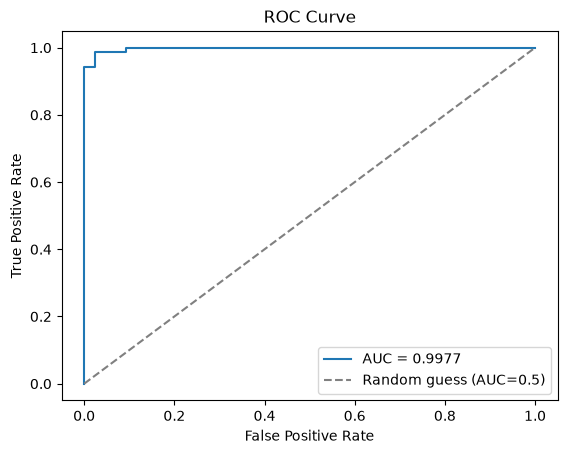

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

 AUC is the area under the curve and it represents the perforemance of the model without relying on any specific threshold. A high AUC means that the model can distinguish between  positive and negative cases well.